# Melting-Ice 🪫
### Do 3x ETFs like TQQQ really 'decay to zero' — so you must never hold them?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Always decays to zero?: Busted](https://img.shields.io/badge/Always_decays_to_zero%3F-Busted-8b949e?style=flat-square)

Every warning about leveraged ETFs says the same thing: *volatility decay* will bleed a 3x fund to zero, so never hold it more than a day. We take the decay *mechanic* literally — rebuild a 3x fund from the index, day by day — check it really matches TQQQ and UPRO, and ask the only question that matters: did they actually decay? (They didn't — they soared. The real catch is something else entirely.)

> 📓 **This is the plain-language layer.** The exact identity, the drag-vs-drift maths and the break-even volatility are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Educational, reproducible research — every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (melting_ice/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from melting_ice import data, strategy

AS_OF = "2026-06-12"
under, letf, meta = data.load_pair("TQQQ", end=AS_OF)   # QQQ -> TQQQ (3x)
uc, lc = under["close"], letf["close"]
nav  = strategy.simulate_letf(uc, k=3.0)                # simulated 3x from QQQ
real = lc / lc.iloc[0]                                  # real TQQQ, base 1
naive = strategy.naive_k_curve(uc, k=3.0)               # the "3x the period return" line
under_n = uc / uc.iloc[0]                               # QQQ, base 1
print(f"TQQQ pair: {meta['start']} -> {meta['end']}  ({meta['n']:,} rows)")
print(f"fingerprints: QQQ={data.fingerprint(under)}  TQQQ={data.fingerprint(letf)}")
print(f"real TQQQ final x{real.iloc[-1]:.1f}   sim final x{nav.iloc[-1]:.1f}   naive-3x x{naive.iloc[-1]:.1f}")


TQQQ pair: 2010-02-11 -> 2026-06-12  (4,109 rows)
fingerprints: QQQ=2bc863129115  TQQQ=5ad580bd5ea3
real TQQQ final x376.2   sim final x368.9   naive-3x x55.1


## The answer first 🎯

| Question | Answer |
|---|---|
| Did TQQQ 'decay to zero' since 2010? | **No** — it returned **43.9%/yr** and grew **376x**, vs **19.8%/yr** for plain QQQ. |
| Is 'volatility decay' real at all? | **Yes, exactly** — but it's a *race* against compounding. In the 2010s trend, **compounding won by a mile**. |
| So what's the real danger? | The **drawdown**: TQQQ fell **-81.7%** peak-to-trough (QQQ only -35.1%). That's the catch, not a decay law. |

## 1 · The claim

*"Leveraged ETFs are toxic. Daily rebalancing means **volatility decay** guarantees they bleed toward zero over time. **Never** hold a 3x ETF more than a single day."* It's in every broker disclosure and every finance explainer.

## 2 · So what?

If it were a *law*, anyone holding TQQQ long-term would be doomed by maths alone — and the thousands who did since 2010 should have been wiped out. Instead TQQQ is one of the best-performing tickers of the decade. Either the warning is wrong, or something subtle is going on. Both, it turns out.

## 3 · How would we even know?

We rebuild a 3x fund from QQQ's daily returns the way the real fund does it — reset to 3x every day, charge a realistic ~5%/yr all-in cost — and first **check it matches the real TQQQ**. Then we compare it to the naive *"3x the index's total move"* a believer pictures. If decay were a law, the real fund would always end *below* that line. Let's look.

## 4 · The teardown — let's actually look

First: does our rebuilt 3x match the **real** TQQQ?

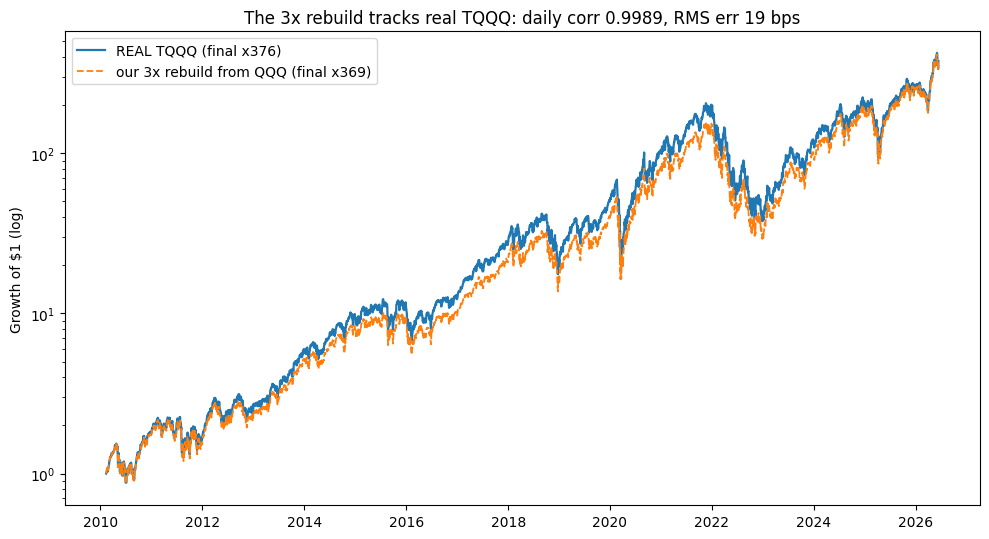

daily-return correlation 0.9989, final NAV ratio sim/real 0.981


In [2]:
rep = strategy.reproduction_error(uc, lc, k=3.0)
fig, ax = plt.subplots(figsize=(10,5.5))
ax.plot(real, label=f"REAL TQQQ (final x{real.iloc[-1]:.0f})", lw=1.6)
ax.plot(nav, '--', label=f"our 3x rebuild from QQQ (final x{nav.iloc[-1]:.0f})", lw=1.3)
ax.set_yscale('log'); ax.set_ylabel('Growth of $1 (log)'); ax.legend()
ax.set_title(f"The 3x rebuild tracks real TQQQ: daily corr {rep['corr']:.4f}, RMS err {rep['rms_te_bps']:.0f} bps")
plt.tight_layout(); plt.show()
print(f"daily-return correlation {rep['corr']:.4f}, final NAV ratio sim/real {rep['final_ratio']:.3f}")

The rebuild lands right on top of the real fund — so the daily-resetting mechanic is **exactly** what TQQQ does. Now the decisive picture: the real 3x vs the *"3x the period return"* line the doom story compares against.

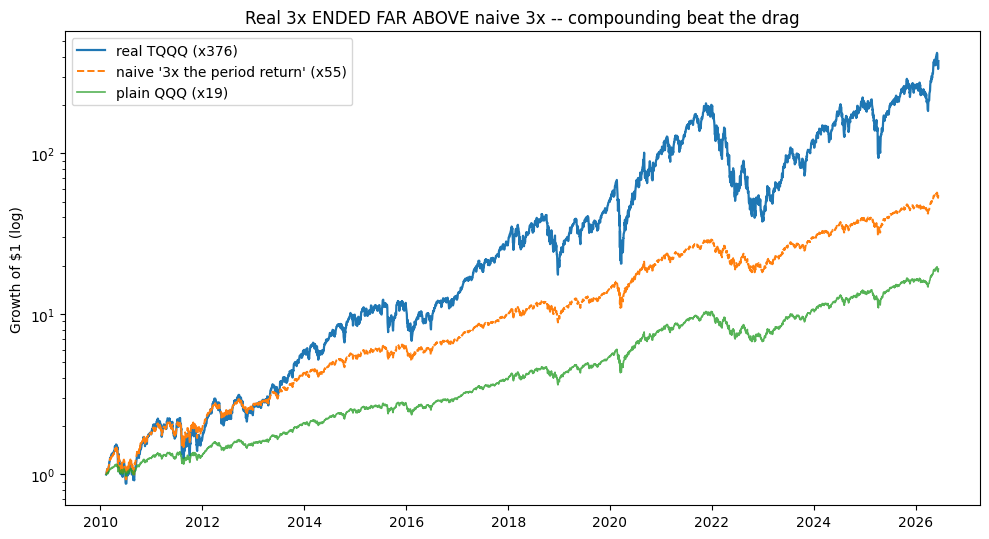

real TQQQ x376  >>  naive-3x x55  -> the opposite of 'decay'


In [3]:
fig, ax = plt.subplots(figsize=(10,5.5))
ax.plot(real, label=f"real TQQQ (x{real.iloc[-1]:.0f})", lw=1.6)
ax.plot(naive, label=f"naive '3x the period return' (x{naive.iloc[-1]:.0f})", lw=1.4, ls='--')
ax.plot(under_n, label=f"plain QQQ (x{under_n.iloc[-1]:.0f})", lw=1.2, alpha=.8)
ax.set_yscale('log'); ax.set_ylabel('Growth of $1 (log)'); ax.legend()
ax.set_title('Real 3x ENDED FAR ABOVE naive 3x -- compounding beat the drag'); plt.tight_layout(); plt.show()
print(f"real TQQQ x{real.iloc[-1]:.0f}  >>  naive-3x x{naive.iloc[-1]:.0f}  -> the opposite of 'decay'")

There it is: real TQQQ ended at **~376x**, the naive-3x line at only **~55x**. In a strong trend, resetting to 3x every day compounds gains *on top of* gains — the exact opposite of bleeding away. So where does the decay story come from? From **choppy, trendless** years. Watch what regime does to it:

               QQQ %  real 3x %  naive 3x %
regime                                     
2010-21 bull 922.200 14,566.500   2,766.600
2018 chop     -1.800    -23.100      -5.500
2022 selloff -33.200    -79.300     -99.700


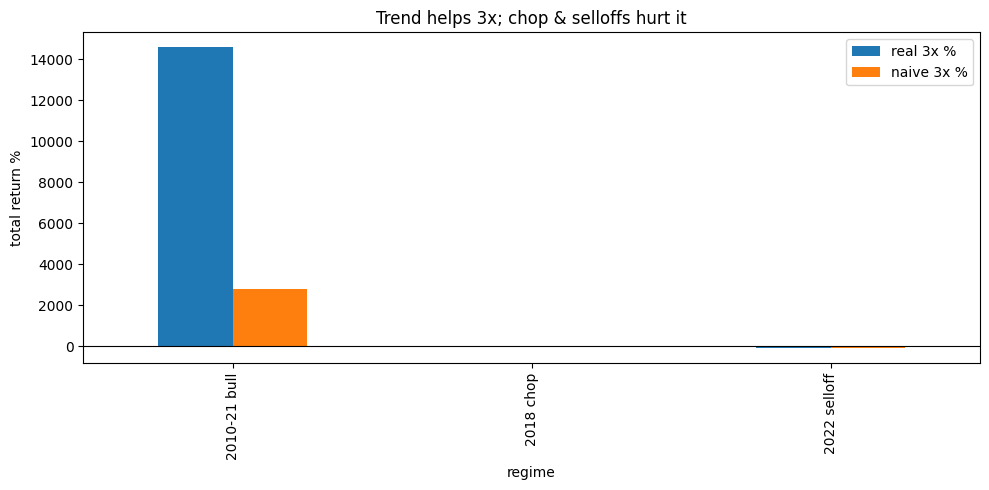

In [4]:
qqq = data.load_real('QQQ', mode='total_return')['close'].loc[:AS_OF]
rows = []
for lo, hi, lab in [('2010-02-11','2021-12-31','2010-21 bull'),('2018-01-01','2018-12-31','2018 chop'),('2022-01-01','2022-12-31','2022 selloff')]:
    seg = qqq.loc[lo:hi]; rvn = strategy.realized_vs_naive(seg, k=3.0)
    rows.append((lab, (seg.iloc[-1]/seg.iloc[0]-1)*100, (rvn['realized_final']-1)*100, (rvn['naive_final']-1)*100))
tbl = pd.DataFrame(rows, columns=['regime','QQQ %','real 3x %','naive 3x %']).set_index('regime')
print(tbl.round(1))
ax = tbl[['real 3x %','naive 3x %']].plot.bar(figsize=(10,5))
ax.axhline(0, color='k', lw=.8); ax.set_ylabel('total return %'); ax.set_title('Trend helps 3x; chop & selloffs hurt it'); plt.tight_layout(); plt.show()

In the **bull** the 3x crushed naive-3x; in the **2018 chop** a flat QQQ year (−1.8%) turned into **-23.1%** for the 3x (decay bit hard); in the **2022 selloff** it was a **-79.3%** wipeout. So the warning is *right in chop and crashes, wrong in trends*. It's not a law — it's **path-dependent**.

## 5 · The verdict

- **Always decays to zero? → Busted.** Real TQQQ ended x376 vs naive-3x x55; UPRO x123 vs x31. Decay is path-dependent, not guaranteed.
- **The decay mechanic is real.** Our exact daily rebuild matches the real funds (corr 0.9989). In flat/choppy tapes it genuinely bleeds.
- **The real catch is the drawdown:** **-81.7%** for TQQQ (vs -35.1% for QQQ) — a leveraged bet on the trend continuing, not a free lunch.

## 6 · Could you actually trade it?

You can hold one for years — people did, and got rich on TQQQ in the 2010s. But that was a **leveraged bet on a once-in-a-generation trend**: you earned ~24 extra points/year of return while taking *disproportionately* more risk (a worse Sharpe than plain QQQ) and an **82% drawdown** that can take a decade to recover. As *"a thing doomed by decay"* it's busted; as *"a safe buy-and-hold"* it's a mirage — it's pure regime-dependent leverage.

## 7 · Going further 🚪

- At what **volatility** does decay finally overwhelm a 3x sleeve? (We compute the break-even in the quants notebook — ~40% annualised.)
- Does a **2x** fund (QLD, SSO) give most of the upside with a survivable drawdown?
- Would a simple **trend filter** (only hold 3x above the 200-day) dodge the −80% craters? Fork it and try.